<a href="https://colab.research.google.com/github/daviseemann/turbofan-rul-prediction-cmapss/blob/production/notebooks/MLP-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount(
    "/content/drive/",
)
import os

os.chdir(
    "/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data"
)

Mounted at /content/drive/


In [2]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

# Importando os arquivos (espaço em branco como delimitador)
df_train = pd.read_csv(train_path, sep="\s+", header=None, names=column_names)
df_test = pd.read_csv(test_path, sep="\s+", header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep="\s+", header=None, names=["RUL"])

In [3]:
display(df_train.head())
display(df_test.head())
display(df_rul.head())

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,RUL
0,112
1,98
2,69
3,82
4,91


# Pré-processamento


### Seleção de Sensores

O artigo menciona que apenas 14 dos 21 sensores são usados. Vamos selecionar os mesmos:


In [4]:
# Sensores selecionados conforme o artigo
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21",
]

# Colunas que vamos manter
features_to_keep = ["engine_id", "cycle"] + selected_sensors

# Filtrando os dataframes
df_train = df_train[features_to_keep]
df_test = df_test[features_to_keep]

### Normalização dos Dados

O artigo usa normalização min-max para o intervalo [-1, 1]:


In [56]:
from sklearn.preprocessing import MinMaxScaler

def min_max_normalize(train_df, test_df, features):
    """Normaliza as features para o intervalo [-1, 1] sem data leakage"""
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train_df[features])  # Ajusta apenas no treino

    # Aplica a transformação no treino e no teste
    train_df[features] = scaler.transform(train_df[features])
    test_df[features] = scaler.transform(test_df[features])

    return train_df, test_df, scaler

# Normalizando os dados
features_to_normalize = selected_sensors
df_train, df_test, scaler = min_max_normalize(df_train, df_test, features_to_normalize)

### Criando os RULs para Treino

O artigo usa um modelo de degradação linear por partes com RUL constante inicial (Re):


In [6]:
def create_rul_labels(df, Re, clip_at_zero=True):
    """Cria os rótulos RUL usando o modelo de degradação linear por partes"""
    grouped = df.groupby("engine_id")["cycle"].max().reset_index()
    grouped.columns = ["engine_id", "max_cycle"]

    df = df.merge(grouped, on="engine_id", how="left")
    df["RUL"] = df["max_cycle"] - df["cycle"]

    # Aplica o modelo de degradação linear por partes
    df["RUL"] = np.where(df["RUL"] > Re, Re, df["RUL"])

    return df.drop(columns=["max_cycle"])

# Usando Re=128 conforme sugerido no artigo para FD001
Re = 128
df_train = create_rul_labels(df_train, Re)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rul_by_engine(df, engines_to_plot=5):
    """Plota o RUL ao longo do tempo para algumas engines"""
    # Selecionar engines para visualizar
    engine_ids = df["engine_id"].unique()[:engines_to_plot]

    plt.figure(figsize=(14, 8))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["cycle"], engine_data["RUL"], label=f'Engine {engine_id}')

    plt.xlabel('Cycle')
    plt.ylabel('RUL')
    plt.title('RUL por Engine ID')
    plt.legend()
    plt.grid(True)
    plt.show()


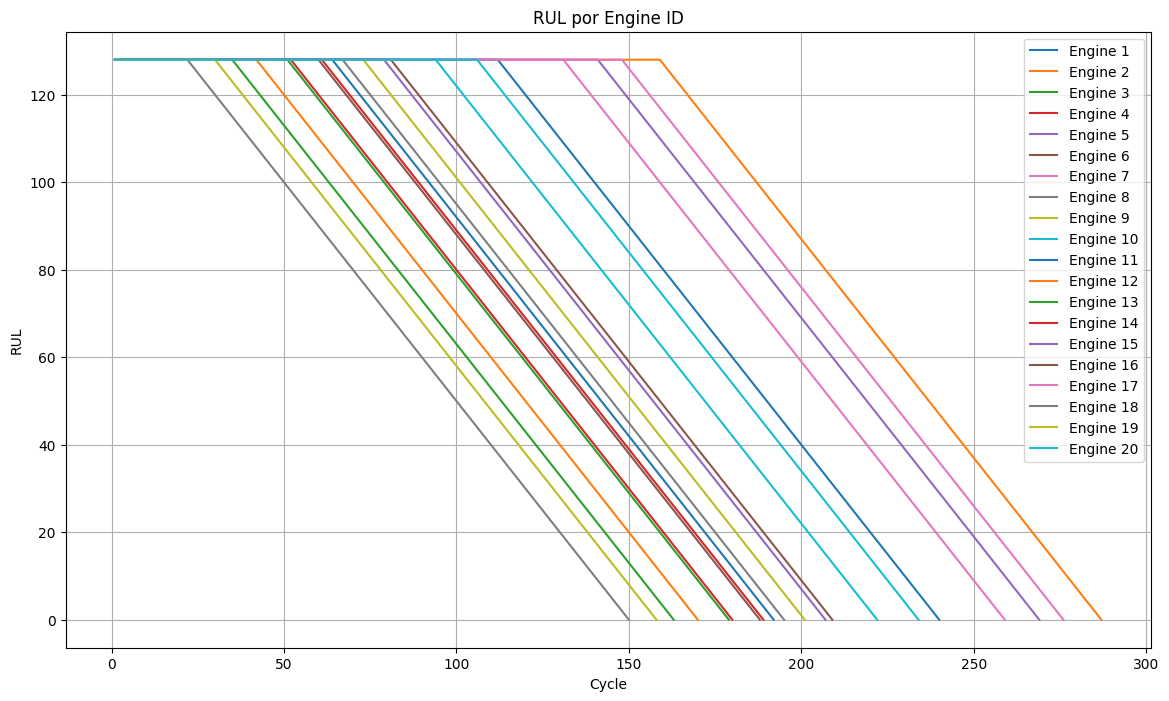

In [8]:
plot_rul_by_engine(df_train, engines_to_plot=20)

### Preparando as Janelas Temporais

O artigo usa janelas temporais com tamanho (nw) e stride (ns):


In [23]:
def create_time_windows(df, window_size, window_stride, sensor_cols):
    """Cria janelas temporais dos dados dos sensores e retorna um DataFrame com info da janela"""
    sequences = []
    labels = []
    engine_ids = []
    last_cycles = []

    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id]
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data["RUL"].values

        # Cria janelas deslizantes
        for i in range(0, len(engine_data) - window_size + 1, window_stride):
            window = sensor_data[i: i + window_size]
            label = rul_data[i + window_size - 1]
            sequences.append(window)
            labels.append(label)
            engine_ids.append(engine_id)
            last_cycles.append(engine_data["cycle"].iloc[i + window_size - 1])

    # Flatten sequences for MLP input
    n_samples = len(sequences)
    n_timesteps = window_size
    n_features = len(sensor_cols)
    flattened_sequences = np.array(sequences).reshape((n_samples, n_timesteps * n_features))

    df_windows = pd.DataFrame({
        'engine_id': engine_ids,
        'last_cycle': last_cycles,
        'data_vector': list(flattened_sequences),  # Correto aqui
        'RUL': labels
    })

    return df_windows

# Parâmetros do artigo para FD001: nw=24, ns=1
window_size = 24
window_stride = 1

# Criando as sequências de treino
sensor_cols = selected_sensors
df_train_windows = create_time_windows(df_train, window_size, window_stride, sensor_cols)

# Separando X_train e y_train
X_train = np.array(list(df_train_windows['data_vector']))
y_train = df_train_windows['RUL'].values

display(df_train_windows.head())


,engine_id,last_cycle,data_vector,RUL
0,1,24,"[-0.6325301204819311, -0.1863963374754718, -0....",128
1,1,25,"[-0.43373493975906285, -0.0939611946806167, -0...",128
2,1,26,"[-0.3132530120481647, -0.2609548724656605, -0....",128
3,1,27,"[-0.3132530120481647, -0.4876825812077499, -0....",128
4,1,28,"[-0.3012048192771317, -0.48506649226072795, -0...",128


### Preparando os Dados de Teste

Para os dados de teste, o artigo usa apenas a última janela de cada motor:


In [24]:
def prepare_test_data(df_test, window_size, sensor_cols):
    """Prepara os dados de teste usando a última janela de cada motor"""
    X_test = []
    engine_ids = []
    n_features = len(sensor_cols)

    for engine_id in df_test['engine_id'].unique():
        engine_data = df_test[df_test['engine_id'] == engine_id]
        sensor_data = engine_data[sensor_cols].values

        # Pega a última janela
        if len(engine_data) >= window_size:
            window = sensor_data[-window_size:]
        else:
            # Preenche com zeros se não houver dados suficientes
            padding = np.zeros((window_size - len(engine_data), n_features))
            window = np.vstack((padding, sensor_data))

        X_test.append(window)
        engine_ids.append(engine_id)

    X_test = np.array(X_test)
    n_samples = X_test.shape[0]
    X_test = X_test.reshape((n_samples, window_size * n_features))

    return X_test, engine_ids


X_test, test_engine_ids = prepare_test_data(df_test, window_size, sensor_cols)

### Carregando os RULs Reais para Teste


In [25]:
# Carregando os RULs reais
true_rul = df_rul["RUL"].values
true_rul.shape

(100,)

# Arquitetura da MLP

In [27]:
import tensorflow as tf
from tensorflow.keras import backend as K

def root_mean_squared_error(y_true, y_pred):
    """Calcula o RMSE garantindo operações em float32"""
    # Converte os inputs para float32 explicitamente
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    squared_diff = tf.square(y_pred - y_true)
    mean_squared = tf.reduce_mean(squared_diff)
    rmse = tf.sqrt(mean_squared)
    return rmse

def rul_health_score(y_true, y_pred):
    """Calcula o RHS garantindo operações em float32"""
    # Converte os inputs para float32 explicitamente
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    d = y_pred - y_true
    # Usando tf.where no lugar de K.switch para maior clareza
    s = tf.where(d < 0,
                tf.exp(-d/13.0) - 1.0,
                tf.exp(d/10.0) - 1.0)
    return tf.reduce_mean(s)

In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1_l2

def create_mlp(input_dim, lr=0.001):
    """Cria o modelo MLP com métricas em float32"""
    model = Sequential([
          Dense(20, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l1_l2(l1=0.1, l2=0.2)),
          Dense(20, activation='relu', kernel_regularizer=l1_l2(l1=0.1, l2=0.2)),
          Dense(1, activation='linear', kernel_regularizer=l1_l2(l1=0.1, l2=0.2))
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=[
            "mean_squared_error",
            root_mean_squared_error
        ]
    )
    return model


In [ ]:
# Criando o modelo
input_dim = X_train.shape[1]
model = create_mlp(input_dim,0.0001)
model.summary()

In [107]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    verbose=2
)

Epoch 1/100
29/29 - 4s - 150ms/step - loss: 8651.4805 - mean_squared_error: 8587.4023 - root_mean_squared_error: 92.6153 - val_loss: 9352.4980 - val_mean_squared_error: 9288.9189 - val_root_mean_squared_error: 90.8201
Epoch 2/100
29/29 - 0s - 9ms/step - loss: 8582.9463 - mean_squared_error: 8519.8350 - root_mean_squared_error: 92.2946 - val_loss: 9275.5420 - val_mean_squared_error: 9212.9404 - val_root_mean_squared_error: 90.5214
Epoch 3/100
29/29 - 0s - 6ms/step - loss: 8512.1797 - mean_squared_error: 8450.0156 - root_mean_squared_error: 91.9899 - val_loss: 9196.7100 - val_mean_squared_error: 9134.9971 - val_root_mean_squared_error: 90.2107
Epoch 4/100
29/29 - 0s - 5ms/step - loss: 8418.9990 - mean_squared_error: 8357.6523 - root_mean_squared_error: 91.5844 - val_loss: 9079.0527 - val_mean_squared_error: 9018.0820 - val_root_mean_squared_error: 89.7465
Epoch 5/100
29/29 - 0s - 6ms/step - loss: 8301.9844 - mean_squared_error: 8241.3271 - root_mean_squared_error: 91.1010 - val_loss: 895

In [108]:
def rul_health_score(y_true, y_pred):
    diffs = y_pred - y_true
    scores = np.where(diffs < 0, np.exp(-diffs / 13) - 1, np.exp(diffs / 10) - 1)
    return np.mean(scores)

573/573 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


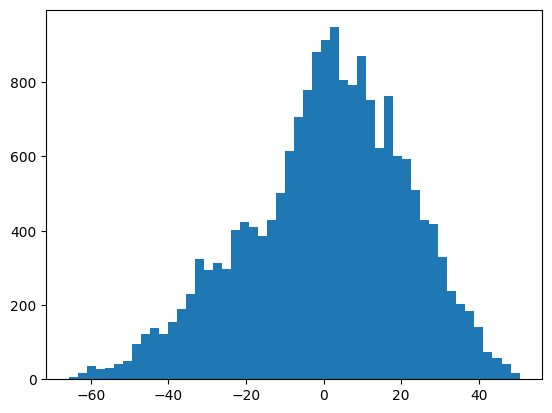

'RHS (Training Set): 10.89'

In [109]:
y_pred_train = model.predict(X_train).flatten()
errors = y_train - y_pred_train
plt.hist(errors, bins=50)
plt.show()

rhs_train = rul_health_score(y_train, y_pred_train)
display(f"RHS (Training Set): {rhs_train:.2f}")

In [110]:
def plot_rul_predictions(df, start=1,stop=1, dataset_type='train'):
    """
    Plota a comparação entre RUL real e RUL predito por engine_id.

    Parâmetros:
    - df: DataFrame contendo as colunas ['engine_id', 'cycle', 'RUL', 'RUL_PREDICTED']
    - engines_to_plot: Quantidade de engines a serem exibidas
    - dataset_type: 'train' ou 'test' (apenas para título)
    """
    engine_ids = df["engine_id"].unique()[start-1:stop]

    plt.figure(figsize=(5, 4))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["last_cycle"], engine_data["RUL"], label=f'Engine {engine_id} - Real', linestyle='-')
        plt.plot(engine_data["last_cycle"], engine_data["RUL_PREDICTED"], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('last_cycle')
    plt.ylabel('RUL')
    plt.title(f'Comparação RUL Real vs. Predito ({dataset_type.capitalize()} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()


573/573 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


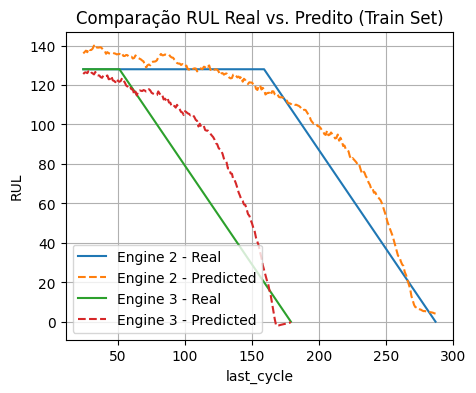

In [111]:
df_train_windows = df_train_windows.reset_index(drop=True)

# Criando o DataFrame de resultados
df_results = df_train_windows[["engine_id", "RUL", "last_cycle"]].copy()

df_results['RUL_PREDICTED'] = model.predict(X_train)

plot_rul_predictions(df_results, start=2,stop=3,dataset_type='train')

In [96]:
y_test_true = df_test.groupby('engine_id')['RUL'].last().values  # RUL real da última janela
y_test_pred = model.predict(X_test).flatten()  # Previsão da última janela por engine


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [113]:
test_rhs = rul_health_score(y_test_true, y_test_pred)
print(f'RUL Health Score no conjunto de teste: {test_rhs:.2f}')


RUL Health Score no conjunto de teste: 0.52


In [114]:
from sklearn.metrics import mean_squared_error
import numpy as np

test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
print(f'RMSE no conjunto de teste: {test_rmse:.2f}')


RMSE no conjunto de teste: 4.70


In [76]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_comparison(rmse_keras, mae_keras, rhs_numpy, rhs_keras):
    """
    Plota um gráfico de barras comparando RMSE, MAE e RHS calculado manualmente vs Keras.
    """
    metrics = ['RMSE (Keras)', 'MAE (Keras)', 'RHS (Manual)', 'RHS (Keras)']
    values = [rmse_keras, mae_keras, rhs_numpy, rhs_keras]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics, values, color=['skyblue', 'orange', 'lightgreen', 'red'])

    # Adiciona os valores no topo das barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

    plt.title('Comparação de Métricas (Keras vs. Manual)')
    plt.ylabel('Valor da Métrica')
    plt.grid(axis='y')
    plt.show()


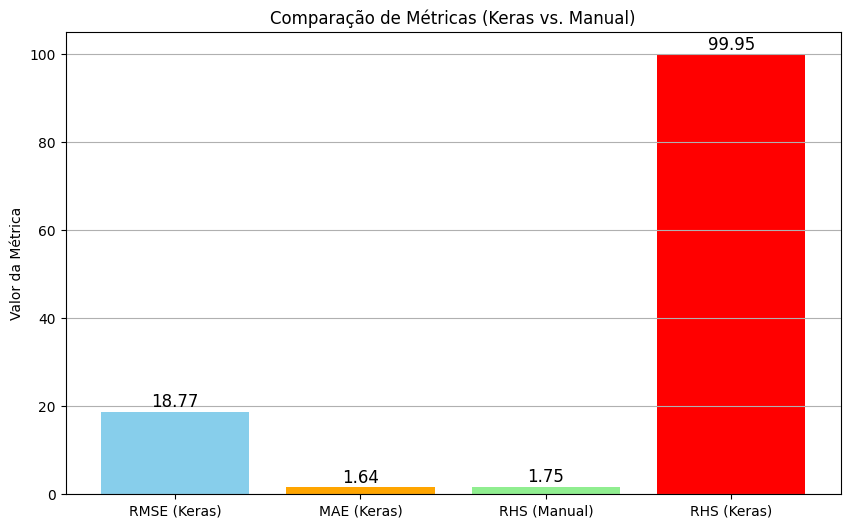

In [77]:
# Exemplo de uso:
# model.evaluate retorna [loss (RMSE), rhs_metric, mae]
results = model.evaluate(X_test, y_test_true, verbose=0)
rmse_keras = results[0]
rhs_keras = results[1]
mae_keras = results[2]

# Calcular RHS manualmente
rhs_numpy = rul_health_score(y_test_true, y_test_pred)

# Gerar o gráfico
plot_metric_comparison(rmse_keras, mae_keras, rhs_numpy, rhs_keras)
